In [1]:

import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:

def prepare_data(data_dir, img_size=(224, 224), batch_size=32):
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    
    train_gen = datagen.flow_from_directory(
        data_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        subset='training',
        shuffle=True
    )
    
    val_gen = datagen.flow_from_directory(
        data_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        subset='validation',
        shuffle=False
    )
    return train_gen, val_gen


In [3]:

def build_densenet_model(input_shape=(224, 224, 3)):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model, base_model


In [4]:

def compile_model(model):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [5]:

def train_model(model, train_gen, val_gen, epochs=10):
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint('densenet_best_model.h5', save_best_only=True)
    ]
    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=callbacks)
    return history


In [6]:

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()


In [7]:

def evaluate_model(model, val_gen):
    val_gen.reset()
    y_true = val_gen.classes
    y_pred = (model.predict(val_gen) > 0.5).astype(int).reshape(-1)

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=val_gen.class_indices.keys()))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_gen.class_indices.keys())
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()


In [8]:

def fine_tune_model(model, base_model, train_gen, val_gen, epochs=5):
    for layer in base_model.layers[-50:]:
        layer.trainable = True

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint('fine_tuned_densenet.h5', save_best_only=True)
    ]

    history_ft = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=callbacks)
    return history_ft


Found 2013 images belonging to 3 classes.
Found 502 images belonging to 3 classes.


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6952 - loss: 0.3799

63/63 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.6956 - loss: 0.3790 - val_accuracy: 0.7331 - val_loss: 0.3052
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7329 - loss: 0.2366

63/63 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.7328 - loss: 0.2376 - val_accuracy: 0.7331 - val_loss: 0.2866
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7187 - loss: 0.3410

63/63 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.7189 - loss: 0.3405 - val_accuracy: 0.7331 - val_loss: 0.2831
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7273 - loss: 0.2789

63/63 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.7273 - loss: 0.2793 - val_accuracy: 0.7331 - val_loss: 0.2829
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7471 - loss: 0.3119

63/63 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.7468 - loss: 0.3119 - val_accuracy: 0.7331 - val_loss: 0.2802
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.7301 - loss: 0.2885 - val_accuracy: 0.7331 - val_loss: 0.2890
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.7198 - loss: 0.2782 - val_accuracy: 0.7331 - val_loss: 0.3076
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.7306 - loss: 0.2503 - val_accuracy: 0.7331 - val_loss: 0.2883


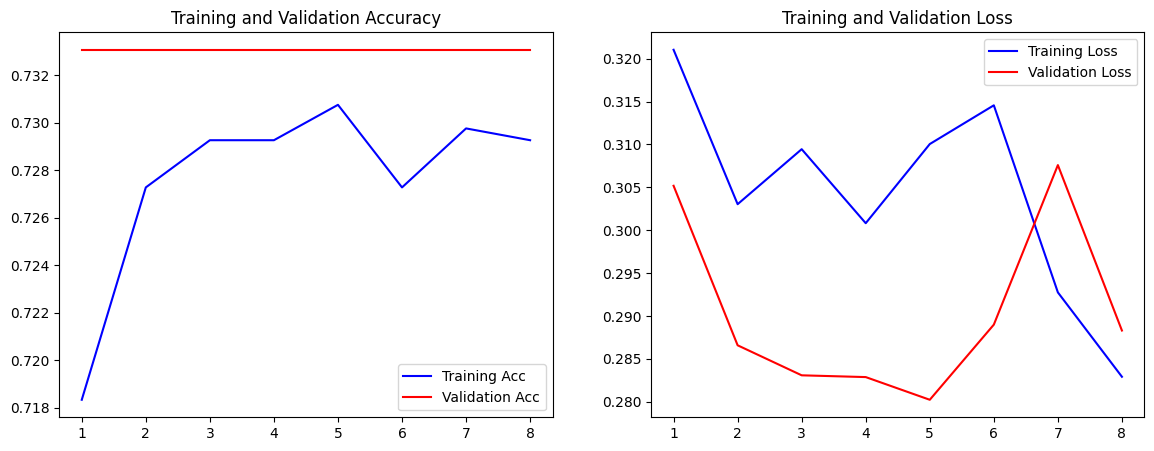

16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step
Classification Report:
              precision    recall  f1-score   support

        Test       0.00      0.00      0.00        87
       Train       0.73      1.00      0.85       368
  Validation       0.00      0.00      0.00        47

    accuracy                           0.73       502
   macro avg       0.24      0.33      0.28       502
weighted avg       0.54      0.73      0.62       502



c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

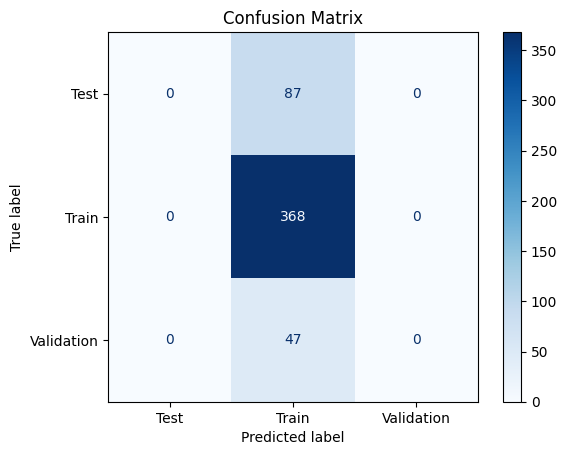

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7327 - loss: 0.2674

63/63 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.7326 - loss: 0.2681 - val_accuracy: 0.7331 - val_loss: 0.2812
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7320 - loss: 0.3402

63/63 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.7320 - loss: 0.3396 - val_accuracy: 0.7331 - val_loss: 0.2798
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.7355 - loss: 0.3286 - val_accuracy: 0.7331 - val_loss: 0.2822
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.7188 - loss: 0.3300 - val_accuracy: 0.7331 - val_loss: 0.2858
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.7228 - loss: 0.3270 - val_accuracy: 0.7331 - val_loss: 0.2872


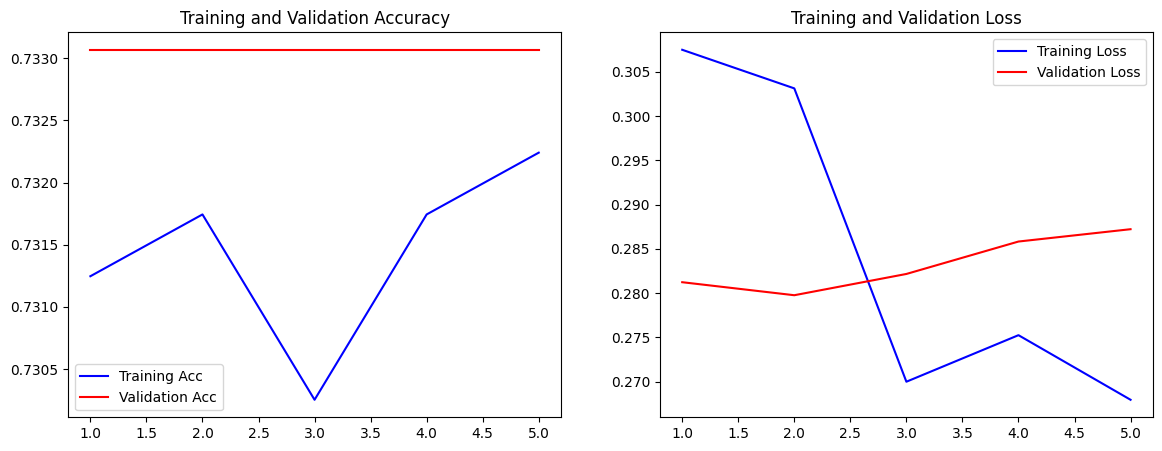

16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step
Classification Report:
              precision    recall  f1-score   support

        Test       0.00      0.00      0.00        87
       Train       0.73      1.00      0.85       368
  Validation       0.00      0.00      0.00        47

    accuracy                           0.73       502
   macro avg       0.24      0.33      0.28       502
weighted avg       0.54      0.73      0.62       502



c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

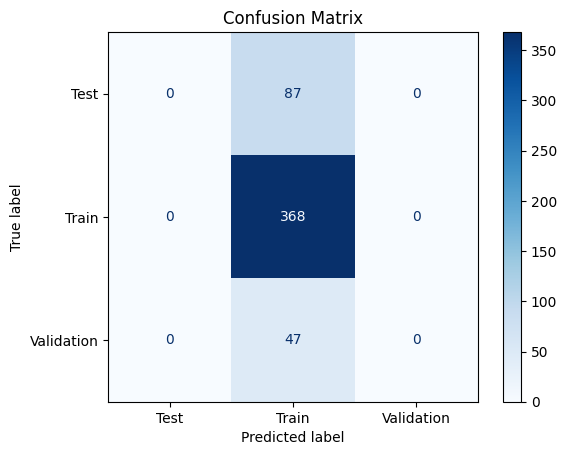

In [11]:

# Path to dataset (change this to your dataset root path)
data_path = r"C:\Users\user\Documents\HEALTHCARE\HEALTHCARE\DATA_nonstructurées\Brain_Stroke_CT-SCAN_image"

# Step-by-step execution
train_gen, val_gen = prepare_data(data_path)
model, base_model = build_densenet_model()
compile_model(model)
history = train_model(model, train_gen, val_gen, epochs=10)
plot_training_history(history)
evaluate_model(model, val_gen)

# Optional: Fine-tuning
history_ft = fine_tune_model(model, base_model, train_gen, val_gen, epochs=5)
plot_training_history(history_ft)
evaluate_model(model, val_gen)


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


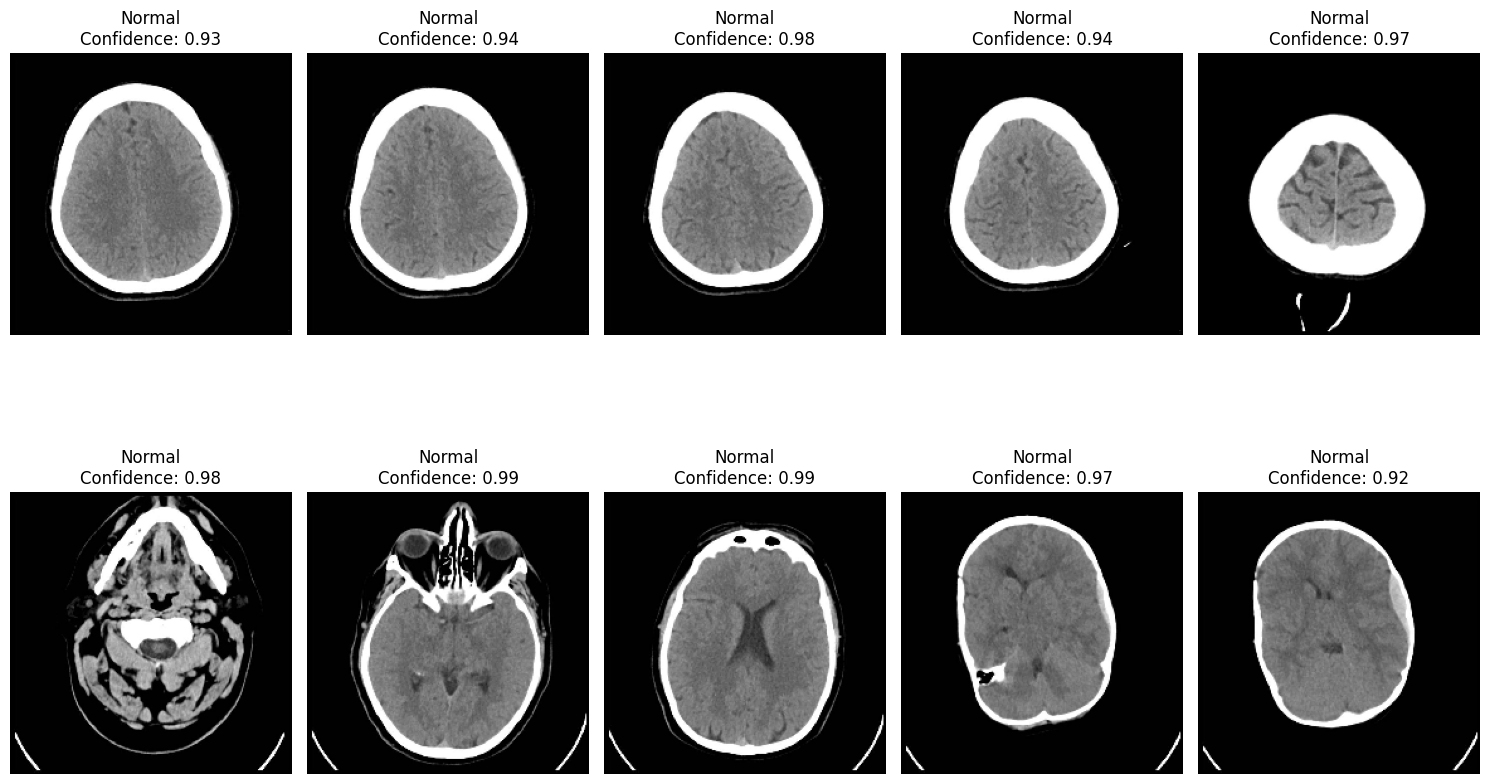

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
from tensorflow.keras.preprocessing import image  # ✅ This line is essential

# Define paths and class names
val_dir = r"C:\Users\user\Documents\HEALTHCARE\HEALTHCARE\DATA_nonstructurées\Brain_Stroke_CT-SCAN_image\Validation"
class_names = ['Normal', 'Stroke']

# Load the trained model
model = tf.keras.models.load_model('fine_tuned_densenet.h5')

# Function to load and preprocess an image
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)
    return np.expand_dims(img_array, axis=0), img

# Sample some images from the validation set
num_samples = 5
sample_images = []

valid_extensions = ('.jpg', '.jpeg', '.png')

for class_name in class_names:
    class_folder = os.path.join(val_dir, class_name)
    files = [f for f in os.listdir(class_folder) if f.lower().endswith(valid_extensions)]
    sample_images.extend([os.path.join(class_folder, f) for f in files[:num_samples]])

# Plot predictions
plt.figure(figsize=(15, 10))
for i, img_path in enumerate(sample_images):
    img_array, original_img = load_and_preprocess_image(img_path)
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    plt.subplot(2, num_samples, i + 1)
    plt.imshow(original_img)
    plt.title(f'{predicted_class}\nConfidence: {confidence:.2f}')
    plt.axis('off')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


C:\Users\user\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


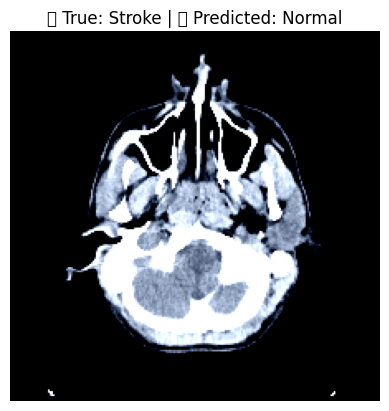

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


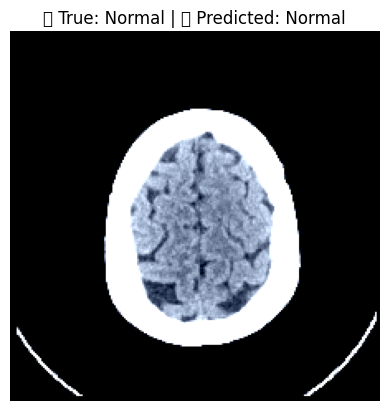

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


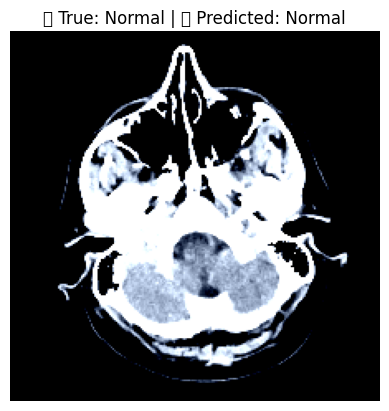

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


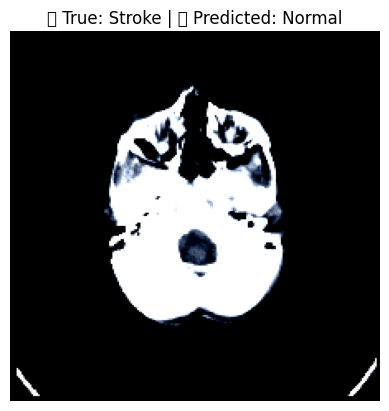

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


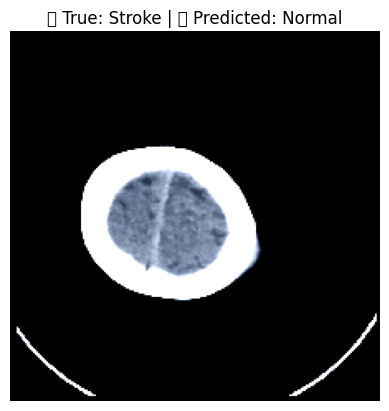

: 

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Number of examples to display
num_examples = 5

# Loop through the first few batches and images
for i in range(num_examples):
    img_batch, label_batch = test_generator[i]
    img = img_batch[0]
    label = label_batch[0]

    # Predict using the model
    pred = model.predict(tf.expand_dims(img, axis=0))[0]

    # Decode true and predicted labels
    true_label = class_names[np.argmax(label)]
    predicted_label = class_names[np.argmax(pred)]

    # Show image with prediction
    plt.imshow((img + 1) / 2)  # Normalize back if you used preprocessing that centered around 0
    plt.title(f"✅ True: {true_label} | 🔍 Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()
